In [1]:
%load_ext autoreload
%autoreload 2

In [46]:
import numpy as np
import csv 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import ConfusionMatrixDisplay
import umap
from plotting import save_plot_scatter, save_confusion_matrix
import matplotlib.pyplot as plt

In [16]:
# Load data
X = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_in - Copy.csv', delimiter=',')
y = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/train_out - Copy.csv', delimiter=',').ravel().astype(int)
X_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_in - Copy.csv', delimiter=',')
y_test = np.loadtxt(r'/local/s4099699/IDL/assignment_1/data/test_out - Copy.csv', delimiter=',').astype(int)


### Task 1.1

In [8]:
unique_labels = np.unique(y)
means = np.array([X[y == label].mean(axis=0) for label in unique_labels])

n_labels = unique_labels.shape[0]
dist_matrix = []
for i in range(n_labels):
    dist_row = []
    for j in range(n_labels):
        euclidean_dist = np.linalg.norm(means[i]-means[j])
        dist_row.append(euclidean_dist)
    dist_matrix.append(dist_row)
dist_matrix = np.array(dist_matrix)
np.set_printoptions(precision=2, suppress=True, linewidth=100) # Comment out to print normally
print(dist_matrix) # Uncomment to check matrix

[[ 0.   14.45  9.33  9.14 10.77  7.52  8.15 11.86  9.91 11.49]
 [14.45  0.   10.13 11.73 10.17 11.12 10.61 10.74 10.09  9.93]
 [ 9.33 10.13  0.    8.18  7.93  7.91  7.33  8.87  7.08  8.89]
 [ 9.14 11.73  8.18  0.    9.09  6.12  9.3   8.92  7.02  8.35]
 [10.77 10.17  7.93  9.09  0.    8.    8.78  7.58  7.38  6.01]
 [ 7.52 11.12  7.91  6.12  8.    0.    6.7   9.21  6.97  8.26]
 [ 8.15 10.61  7.33  9.3   8.78  6.7   0.   10.89  8.59 10.44]
 [11.86 10.74  8.87  8.92  7.58  9.21 10.89  0.    8.47  5.43]
 [ 9.91 10.09  7.08  7.02  7.38  6.97  8.59  8.47  0.    6.4 ]
 [11.49  9.93  8.89  8.35  6.01  8.26 10.44  5.43  6.4   0.  ]]


### Task 1.2

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
plot_scatter(X_pca, y, "pca_plot.png")

X_tsne = TSNE(n_components=2).fit_transform(X)
print(X_tsne.shape)
plot_scatter(X_tsne, y, "tsne_plot.png")

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)
print(X_umap.shape)
plot_scatter(X_umap, y, "umap_plot.png")

# plot PCA centres
X_pca_centres = pca.fit_transform(means)
plot_scatter(X_pca_centres, unique_labels, "pca_centres_plot.png")

### Task 1.3

In [9]:
def centre_predictions(string, X, y):
    """
    uses euclidean distance from label means to predict class
    """
    predictions = []
    losses = []
    for idx, x_i in enumerate(X):
        x_i_broadcasted = np.broadcast_to(x_i, means.shape)
        dist = np.linalg.norm(x_i_broadcasted-means, axis=1)
        pred_y = np.argmin(dist)
        loss = 1 if pred_y == y[idx] else 0
        predictions.append(pred_y)
        losses.append(loss)

    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

    return predictions, losses

train_centre_pred, _ = centre_predictions("(train)",X, y)

test_centre_pred, _ = centre_predictions("(test)", X_test, y_test)

(train) Percentage of true predictions: 0.8635
(test) Percentage of true predictions: 0.8040


### Task 1.4

In [11]:
neigh = KNeighborsClassifier()
neigh.fit(X,y)

train_pred, test_pred = neigh.predict(X), neigh.predict(X_test)

print(X.shape, train_pred.shape)
train_loss_arr = np.where(train_pred == y, 1, 0)
test_loss_arr = np.where(test_pred == y_test, 1, 0)

def print_pred_perc(string, losses):
    percentage_true_pred = np.sum(losses) / len(losses)
    print (string, f"Percentage of true predictions: {percentage_true_pred:.4f}")

print_pred_perc("(train)", train_loss_arr)
print_pred_perc("(test)", test_loss_arr)

# Confusion matrices

print("Shapes:", len(train_centre_pred), y.shape)

save_confusion_matrix(train_centre_pred, y, "cm_centre_pred_train.png", "Confusion Matrix: using train label centres (train).")
save_confusion_matrix(test_centre_pred, y_test, "cm_centre_pred_test.png", "Confusion Matrix: using train label centres (test).")
save_confusion_matrix(train_pred, y, "cm_knn_pred_train.png", "Confusion Matrix: using knn with train labels (train).")
save_confusion_matrix(test_pred, y_test, "cm_knn_pred_test.png", "Confusion Matrix: using knn with train labels (test).")

(1707, 256) (1707,)
(train) Percentage of true predictions: 0.9660
(test) Percentage of true predictions: 0.9080
Shapes: 1707 (1707,)


## Task 2

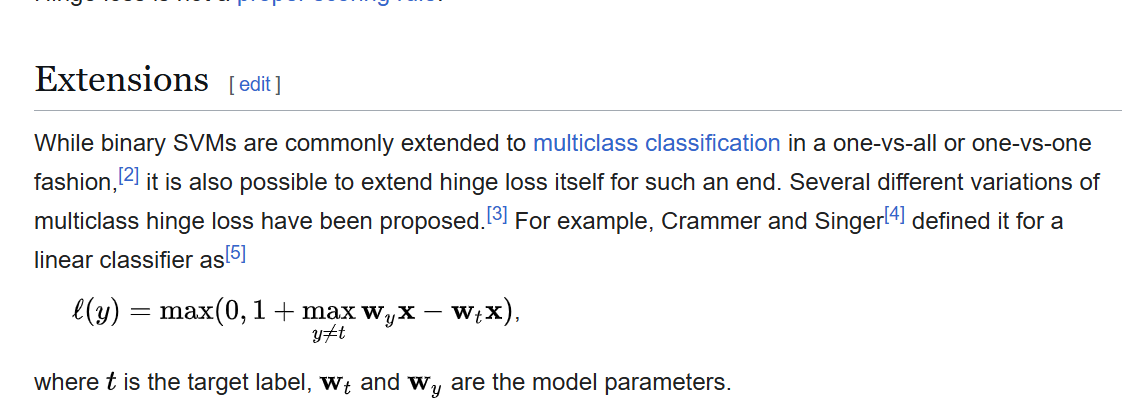

Epoch 1 | Avg loss: 2.347672
Epoch 2 | Avg loss: 75.100809
Epoch 3 | Avg loss: 184.211950
Epoch 4 | Avg loss: 126.758928
Epoch 5 | Avg loss: 76.632695
Epoch 6 | Avg loss: 84.356422
Epoch 7 | Avg loss: 46.519564
Epoch 8 | Avg loss: 45.257964
Epoch 9 | Avg loss: 35.378215
Epoch 10 | Avg loss: 9.466766
(Test) | Avg loss: 6.504504| Accuracy: 0.805000


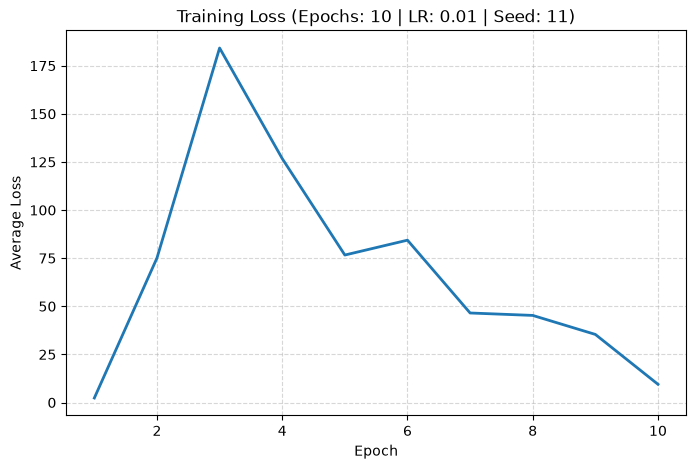

Epoch 1 | Avg loss: 2.420977
Epoch 2 | Avg loss: 82.537329
Epoch 3 | Avg loss: 181.117548
Epoch 4 | Avg loss: 170.824900
Epoch 5 | Avg loss: 98.142109
Epoch 6 | Avg loss: 66.844770
Epoch 7 | Avg loss: 50.201012
Epoch 8 | Avg loss: 54.278227
Epoch 9 | Avg loss: 39.104271
Epoch 10 | Avg loss: 14.579542
Epoch 11 | Avg loss: 6.981839
Epoch 12 | Avg loss: 5.681733
Epoch 13 | Avg loss: 3.227188
Epoch 14 | Avg loss: 2.900695
Epoch 15 | Avg loss: 2.751725
Epoch 16 | Avg loss: 2.632468
Epoch 17 | Avg loss: 2.625075
Epoch 18 | Avg loss: 2.526027
Epoch 19 | Avg loss: 2.478311
Epoch 20 | Avg loss: 2.581976
Epoch 21 | Avg loss: 2.860477
Epoch 22 | Avg loss: 3.418597
Epoch 23 | Avg loss: 3.982047
Epoch 24 | Avg loss: 6.223118
Epoch 25 | Avg loss: 7.550596
Epoch 26 | Avg loss: 10.961602
Epoch 27 | Avg loss: 4.864835
Epoch 28 | Avg loss: 3.622251
Epoch 29 | Avg loss: 2.478900
Epoch 30 | Avg loss: 1.682059
Epoch 31 | Avg loss: 1.226971
Epoch 32 | Avg loss: 1.128556
Epoch 33 | Avg loss: 1.061564
Epoch 3

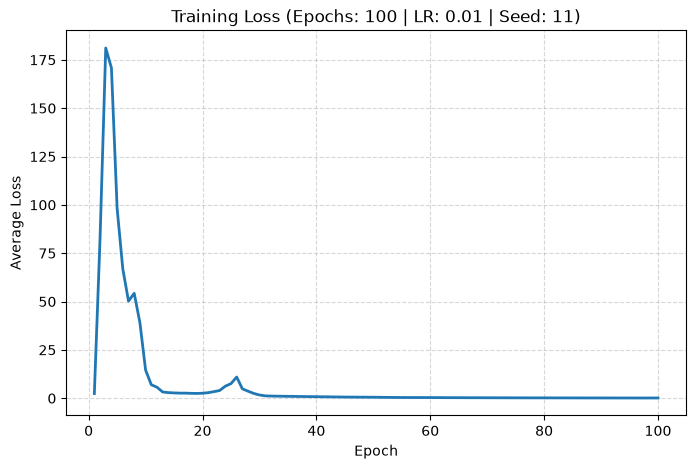

Epoch 1 | Avg loss: 2.319144
Epoch 2 | Avg loss: 63.615236
Epoch 3 | Avg loss: 175.774140
Epoch 4 | Avg loss: 146.577442
Epoch 5 | Avg loss: 90.735023
Epoch 6 | Avg loss: 66.283488
Epoch 7 | Avg loss: 53.343329
Epoch 8 | Avg loss: 51.835609
Epoch 9 | Avg loss: 24.111673
Epoch 10 | Avg loss: 12.765444
Epoch 11 | Avg loss: 10.554741
Epoch 12 | Avg loss: 6.310406
Epoch 13 | Avg loss: 6.565893
Epoch 14 | Avg loss: 6.542094
Epoch 15 | Avg loss: 6.978932
Epoch 16 | Avg loss: 5.944233
Epoch 17 | Avg loss: 5.325607
Epoch 18 | Avg loss: 3.688726
Epoch 19 | Avg loss: 2.693471
Epoch 20 | Avg loss: 2.005823
Epoch 21 | Avg loss: 1.703414
Epoch 22 | Avg loss: 1.528760
Epoch 23 | Avg loss: 1.427445
Epoch 24 | Avg loss: 1.341410
Epoch 25 | Avg loss: 1.275311
Epoch 26 | Avg loss: 1.206750
Epoch 27 | Avg loss: 1.148871
Epoch 28 | Avg loss: 1.098996
Epoch 29 | Avg loss: 1.061990
Epoch 30 | Avg loss: 1.036689
Epoch 31 | Avg loss: 0.968409
Epoch 32 | Avg loss: 0.931712
Epoch 33 | Avg loss: 0.882790
Epoch 3

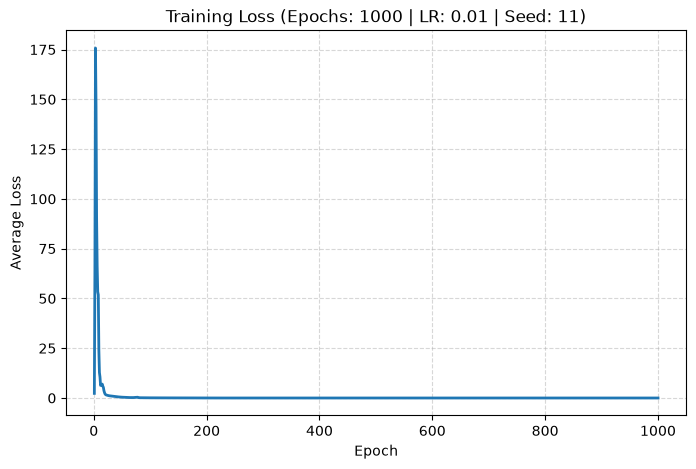

Epoch 1 | Avg loss: 2.381276
Epoch 2 | Avg loss: 611.401186
Epoch 3 | Avg loss: 902.420601
Epoch 4 | Avg loss: 809.714381
Epoch 5 | Avg loss: 557.250812
Epoch 6 | Avg loss: 591.111213
Epoch 7 | Avg loss: 444.456516
Epoch 8 | Avg loss: 310.233198
Epoch 9 | Avg loss: 144.495890
Epoch 10 | Avg loss: 74.670180
(Test) | Avg loss: 48.957804| Accuracy: 0.760000


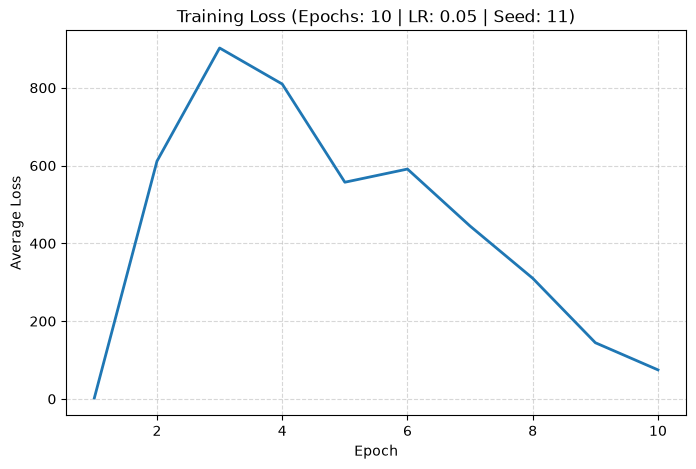

Epoch 1 | Avg loss: 2.318817
Epoch 2 | Avg loss: 349.006331
Epoch 3 | Avg loss: 903.731416
Epoch 4 | Avg loss: 856.414535
Epoch 5 | Avg loss: 490.013511
Epoch 6 | Avg loss: 427.921191
Epoch 7 | Avg loss: 149.319970
Epoch 8 | Avg loss: 51.922395
Epoch 9 | Avg loss: 44.742916
Epoch 10 | Avg loss: 46.808531
Epoch 11 | Avg loss: 42.419238
Epoch 12 | Avg loss: 64.837366
Epoch 13 | Avg loss: 56.444707
Epoch 14 | Avg loss: 44.157233
Epoch 15 | Avg loss: 25.802979
Epoch 16 | Avg loss: 23.010565
Epoch 17 | Avg loss: 17.093698
Epoch 18 | Avg loss: 13.262937
Epoch 19 | Avg loss: 10.629001
Epoch 20 | Avg loss: 8.889093
Epoch 21 | Avg loss: 7.830585
Epoch 22 | Avg loss: 7.238371
Epoch 23 | Avg loss: 6.811970
Epoch 24 | Avg loss: 6.557151
Epoch 25 | Avg loss: 6.159019
Epoch 26 | Avg loss: 5.872134
Epoch 27 | Avg loss: 5.674931
Epoch 28 | Avg loss: 5.840313
Epoch 29 | Avg loss: 5.263446
Epoch 30 | Avg loss: 5.141090
Epoch 31 | Avg loss: 4.674667
Epoch 32 | Avg loss: 4.408773
Epoch 33 | Avg loss: 4.18

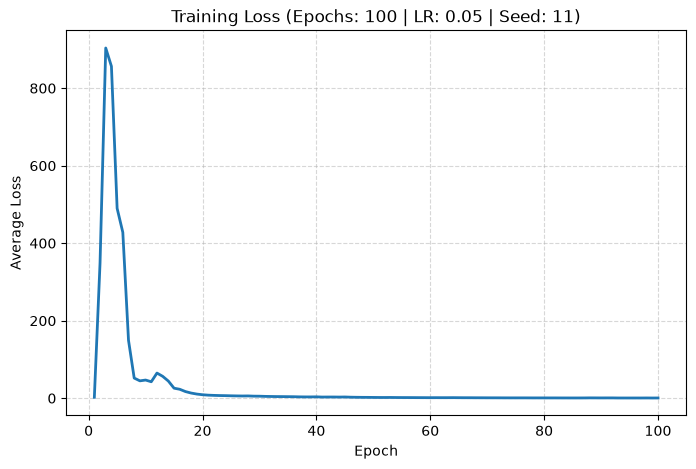

Epoch 1 | Avg loss: 2.300078
Epoch 2 | Avg loss: 384.757513
Epoch 3 | Avg loss: 951.358886
Epoch 4 | Avg loss: 906.914749
Epoch 5 | Avg loss: 595.847240
Epoch 6 | Avg loss: 397.307340
Epoch 7 | Avg loss: 324.895373
Epoch 8 | Avg loss: 300.853299
Epoch 9 | Avg loss: 131.143769
Epoch 10 | Avg loss: 53.485444
Epoch 11 | Avg loss: 33.537083
Epoch 12 | Avg loss: 24.068880
Epoch 13 | Avg loss: 23.053118
Epoch 14 | Avg loss: 19.143109
Epoch 15 | Avg loss: 16.701381
Epoch 16 | Avg loss: 14.346875
Epoch 17 | Avg loss: 12.957323
Epoch 18 | Avg loss: 11.292222
Epoch 19 | Avg loss: 9.778017
Epoch 20 | Avg loss: 8.927808
Epoch 21 | Avg loss: 8.190755
Epoch 22 | Avg loss: 7.668623
Epoch 23 | Avg loss: 7.221974
Epoch 24 | Avg loss: 6.860830
Epoch 25 | Avg loss: 6.564555
Epoch 26 | Avg loss: 6.284148
Epoch 27 | Avg loss: 6.238132
Epoch 28 | Avg loss: 5.788151
Epoch 29 | Avg loss: 5.792601
Epoch 30 | Avg loss: 5.340690
Epoch 31 | Avg loss: 5.111062
Epoch 32 | Avg loss: 5.011898
Epoch 33 | Avg loss: 4.7

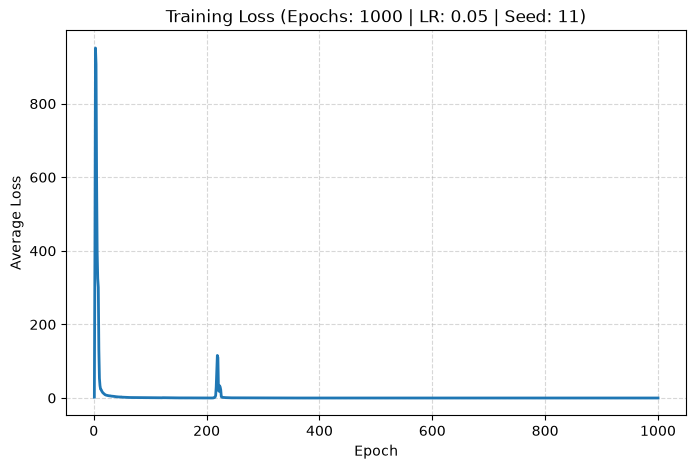

Epoch 1 | Avg loss: 2.326225
Epoch 2 | Avg loss: 10.134130
Epoch 3 | Avg loss: 19.275744
Epoch 4 | Avg loss: 20.708342
Epoch 5 | Avg loss: 13.303213
Epoch 6 | Avg loss: 10.902095
Epoch 7 | Avg loss: 8.864501
Epoch 8 | Avg loss: 5.715264
Epoch 9 | Avg loss: 2.486070
Epoch 10 | Avg loss: 1.271069
(Test) | Avg loss: 0.717276| Accuracy: 0.821000


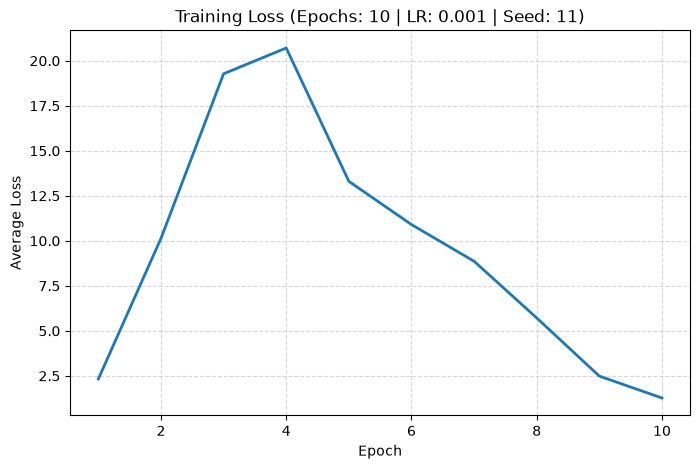

Epoch 1 | Avg loss: 2.312534
Epoch 2 | Avg loss: 6.375591
Epoch 3 | Avg loss: 17.076341
Epoch 4 | Avg loss: 16.585003
Epoch 5 | Avg loss: 10.459119
Epoch 6 | Avg loss: 9.474687
Epoch 7 | Avg loss: 7.040895
Epoch 8 | Avg loss: 4.805778
Epoch 9 | Avg loss: 1.625710
Epoch 10 | Avg loss: 1.484285
Epoch 11 | Avg loss: 0.672682
Epoch 12 | Avg loss: 0.431145
Epoch 13 | Avg loss: 0.376401
Epoch 14 | Avg loss: 0.348777
Epoch 15 | Avg loss: 0.325893
Epoch 16 | Avg loss: 0.303002
Epoch 17 | Avg loss: 0.280932
Epoch 18 | Avg loss: 0.260723
Epoch 19 | Avg loss: 0.241900
Epoch 20 | Avg loss: 0.226676
Epoch 21 | Avg loss: 0.213256
Epoch 22 | Avg loss: 0.202454
Epoch 23 | Avg loss: 0.192844
Epoch 24 | Avg loss: 0.184452
Epoch 25 | Avg loss: 0.176834
Epoch 26 | Avg loss: 0.169921
Epoch 27 | Avg loss: 0.163571
Epoch 28 | Avg loss: 0.157718
Epoch 29 | Avg loss: 0.152293
Epoch 30 | Avg loss: 0.147244
Epoch 31 | Avg loss: 0.142526
Epoch 32 | Avg loss: 0.138103
Epoch 33 | Avg loss: 0.133942
Epoch 34 | Avg l

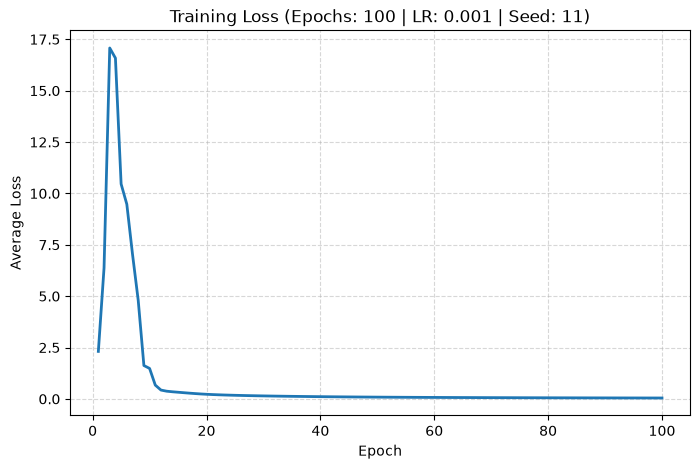

Epoch 1 | Avg loss: 2.304591
Epoch 2 | Avg loss: 8.410701
Epoch 3 | Avg loss: 19.168388
Epoch 4 | Avg loss: 15.485372
Epoch 5 | Avg loss: 9.397052
Epoch 6 | Avg loss: 8.607248
Epoch 7 | Avg loss: 6.650763
Epoch 8 | Avg loss: 3.428624
Epoch 9 | Avg loss: 2.097190
Epoch 10 | Avg loss: 1.469033
Epoch 11 | Avg loss: 1.947009
Epoch 12 | Avg loss: 1.799337
Epoch 13 | Avg loss: 0.621145
Epoch 14 | Avg loss: 0.480775
Epoch 15 | Avg loss: 0.489329
Epoch 16 | Avg loss: 0.500659
Epoch 17 | Avg loss: 0.497436
Epoch 18 | Avg loss: 0.507713
Epoch 19 | Avg loss: 0.463095
Epoch 20 | Avg loss: 0.433129
Epoch 21 | Avg loss: 0.360917
Epoch 22 | Avg loss: 0.305482
Epoch 23 | Avg loss: 0.234738
Epoch 24 | Avg loss: 0.200741
Epoch 25 | Avg loss: 0.186261
Epoch 26 | Avg loss: 0.178052
Epoch 27 | Avg loss: 0.171053
Epoch 28 | Avg loss: 0.164621
Epoch 29 | Avg loss: 0.158643
Epoch 30 | Avg loss: 0.153062
Epoch 31 | Avg loss: 0.147834
Epoch 32 | Avg loss: 0.142922
Epoch 33 | Avg loss: 0.138297
Epoch 34 | Avg lo

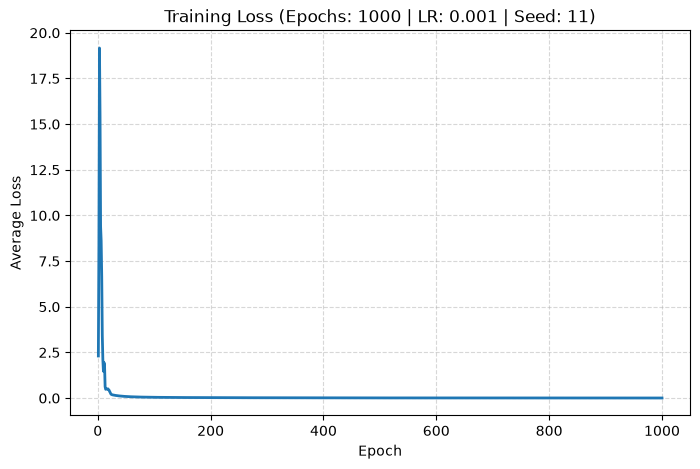

In [48]:
seeds = [11]
lrs = [0.01, 0.05,0.001]
epochs = [10, 100, 1000]

def run_experiment(seeds, lrs, epochs):
    for seed in seeds:
        for lr in lrs:
            for n_epochs in epochs:
                X_in = X.T 
                in_dim = X_in.shape[0]
                n_samples = X_in.shape[1]
                bias = np.ones((1, n_samples))
                T = np.vstack((bias, X_in))
                out_dim = 10
                variance_W = 4 / (in_dim + out_dim)
                W = np.hstack((np.zeros((out_dim, 1)), np.random.normal(0, variance_W, (out_dim, in_dim))))

                loss = []

                for i in range(n_epochs):
                    f = W @ T #logit outputs
                    f_max = np.max(f, axis=0)
                    exp_f = np.exp(f - f_max) # prevent overflow
                    log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                    target_logits = f[y, np.arange(f.shape[1])]
                    L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation

                    loss.append(L)
                    print(f"Epoch {i+1} | Avg loss: {L / n_samples:.6f}")

                    prob = exp_f / np.sum(exp_f, axis=0)
                    prob[y, np.arange(f.shape[1])] -= 1.0
                    dW = prob @ T.T
                    W = W - lr*dW

                T = np.vstack((np.ones((1, y_test.shape[0])), X_test.T))
                predictions = np.argmax(W @ T, axis=0)

                f = W @ T #logit outputs
                f_max = np.max(f, axis=0)
                exp_f = np.exp(f - f_max) # prevent overflow
                log_sum_exp = f_max + np.log(np.sum(exp_f, axis=0)) # factor out the fmax from f_i - fmax in the sum iteration 
                target_logits = f[y_test, np.arange(f.shape[1])]
                L = -np.sum(target_logits - log_sum_exp) #mutliclass cross entropy loss computation
                accuracy = np.sum((predictions == y_test).astype(int))/y_test.shape[0]
                print(f"(Test) | Avg loss: {L / n_samples:.6f}| Accuracy: {accuracy:.6f}")

                title = f"Training Loss (Epochs: {n_epochs} | LR: {lr} | Seed: {seed})"
                plt.figure(figsize=(8, 5))
                plt.plot(range(1, n_epochs + 1), [l / n_samples for l in loss], linewidth=2)
                plt.title(title)
                plt.xlabel("Epoch")
                plt.ylabel("Average Loss")
                plt.grid(True, linestyle="--", alpha=0.5)
                plt.savefig(title + ".png")
                plt.show()

run_experiment(seeds, lrs, epochs)

In [39]:
y_test.shape

(1000,)

In [23]:
prob

NameError: name 'prob' is not defined

In [22]:
f_max

array([[0.32479564, 0.28858313, 0.32085901, ..., 0.27060625, 0.07764201,
        0.16316173]], shape=(1, 1707))

In [14]:
target_logits = f[y.astype(int), np.arange(f.shape[1])]

In [15]:
target_logits

array([-0.01810218, -0.35088227, -0.13141933, ..., -0.37869136,
        0.07764201,  0.0815978 ], shape=(1707,))

In [110]:
y.size

1707

In [122]:
y_binary = -np.ones((out_dim, y.size), dtype=np.int8)
# y_binary[np.arange(y.size), y] = 1
y_binary[y.astype(int), np.arange(y.size)] = 1
y_binary

array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ...,  1, -1, -1],
       [-1, -1, -1, ..., -1, -1,  1],
       [-1, -1, -1, ..., -1,  1, -1]], shape=(10, 1707), dtype=int8)

In [ ]:

np.full(10, -1)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [71]:
a = np.array([1,2,1])
np.tile(a, (3,1))

array([[1, 2, 1],
       [1, 2, 1],
       [1, 2, 1]])